In [2]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 5.0 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/storage/ice-shared/bmed6780/climate_anxiety_survey/climate_anxiety.csv'
df = pd.read_csv(file_path)

print(f"check")

check


In [14]:
# this is based off the "levels of climate-related worry" from the paper
worry_mapping = {
    'not worried': 0,
    'a little': 1,
    'moderately': 2,
    'very': 3,
    'extremely': 4
}
df['worry_numeric'] = df['Q1'].map(worry_mapping)

binary_mapping = {'yes': 1, 'no': 0}
df['impact_daily_binary'] = df['Q3'].map(binary_mapping)

gov_emotion_mapping = {
    'not at all': 0, 
    'a little': 1, 
    'moderately': 2, 
    'very': 3, 
    'extremely': 4
}

# reassurance scale which is also based off of the paper: Q6 (Reassured), Q8_4 (Hopeful), Q8_6 (Valued), Q8_9 (Protected)
# basically the formatting is Q8_4 = Question8 subgroup4
reassurance_cols = ['Q6', 'Q8_4', 'Q8_6', 'Q8_9']
for col in reassurance_cols:
    df[col + '_num'] = df[col].map(gov_emotion_mapping)
df['reassurance_scale'] = df[[col + '_num' for col in reassurance_cols]].mean(axis=1)

# betrayal scale which is also based off of the paper: Q8_1 (Anguished), Q8_2 (Abandoned), Q8_3 (Afraid), Q8_5 (Angry), Q8_7 (Ashamed), Q8_8 (Belittled)
betrayal_cols = ['Q8_1', 'Q8_2', 'Q8_3', 'Q8_5', 'Q8_7', 'Q8_8']
for col in betrayal_cols:
    df[col + '_num'] = df[col].map(gov_emotion_mapping)
df['betrayal_scale'] = df[[col + '_num' for col in betrayal_cols]].mean(axis=1)

# gets rid of the rows that dont matter
df_clean = df.dropna(subset=['worry_numeric']).copy()

# new labels
worry_labels = {0: 'Not Worried', 1: 'A Little', 2: 'Moderately', 3: 'Very', 4: 'Extremely'}
df_clean['worry_label'] = df_clean['worry_numeric'].map(worry_labels)

print("check")

check


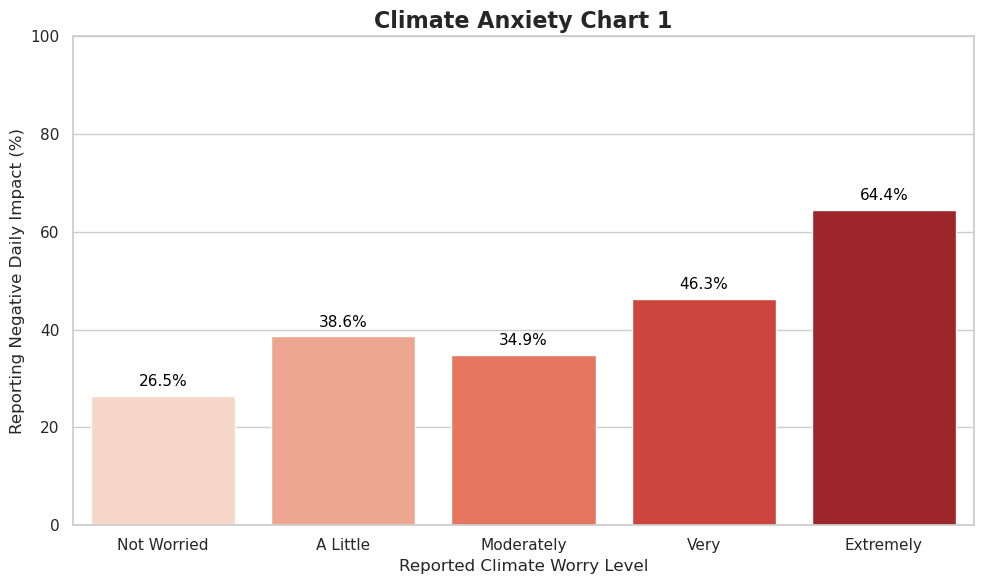

In [17]:
plt.figure(figsize=(10, 6))

impact_percentages = df_clean.groupby('worry_label')['impact_daily_binary'].mean() * 100
order = ['Not Worried', 'A Little', 'Moderately', 'Very', 'Extremely']
impact_percentages = impact_percentages.reindex(order)

ax = sns.barplot(
    x=impact_percentages.index, 
    y=impact_percentages.values, 
    hue=impact_percentages.index, 
    palette="Reds", 
    legend=False
)

plt.title('Climate Anxiety Chart 1', fontsize=16, weight='bold')
plt.xlabel('Reported Climate Worry Level', fontsize=12)
plt.ylabel('Reporting Negative Daily Impact (%)', fontsize=12)
plt.ylim(0, 100)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

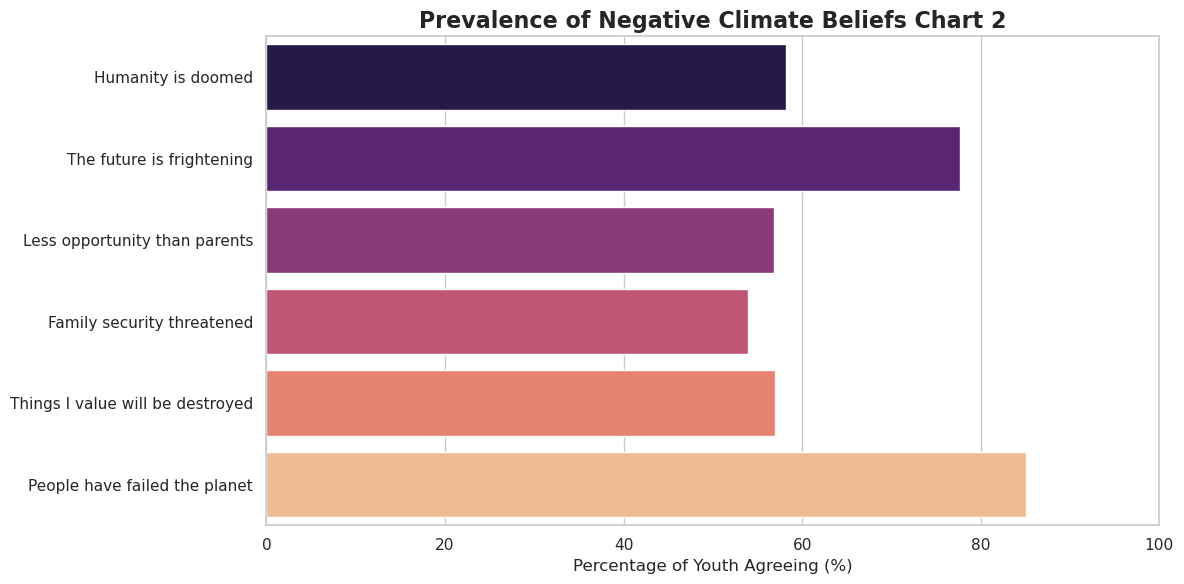

In [18]:
plt.figure(figsize=(12, 6))

negative_thought_cols = ['Q4_2', 'Q4_3', 'Q4_4', 'Q4_5', 'Q4_6', 'Q4_7']
thought_labels = [
    'Humanity is doomed', 'The future is frightening', 'Less opportunity than parents',
    'Family security threatened', 'Things I value will be destroyed', 'People have failed the planet'
]

thought_percentages = []
for col in negative_thought_cols:
    binary_series = df_clean[col].map(binary_mapping)
    thought_percentages.append(binary_series.mean() * 100)

sns.barplot(
    x=thought_percentages, 
    y=thought_labels, 
    hue=thought_labels, 
    palette="magma", 
    legend=False
)

plt.title('Prevalence of Negative Climate Beliefs Chart 2', fontsize=16, weight='bold')
plt.xlabel('Percentage of Youth Agreeing (%)', fontsize=12)
plt.xlim(0, 100)

plt.tight_layout()
plt.show()

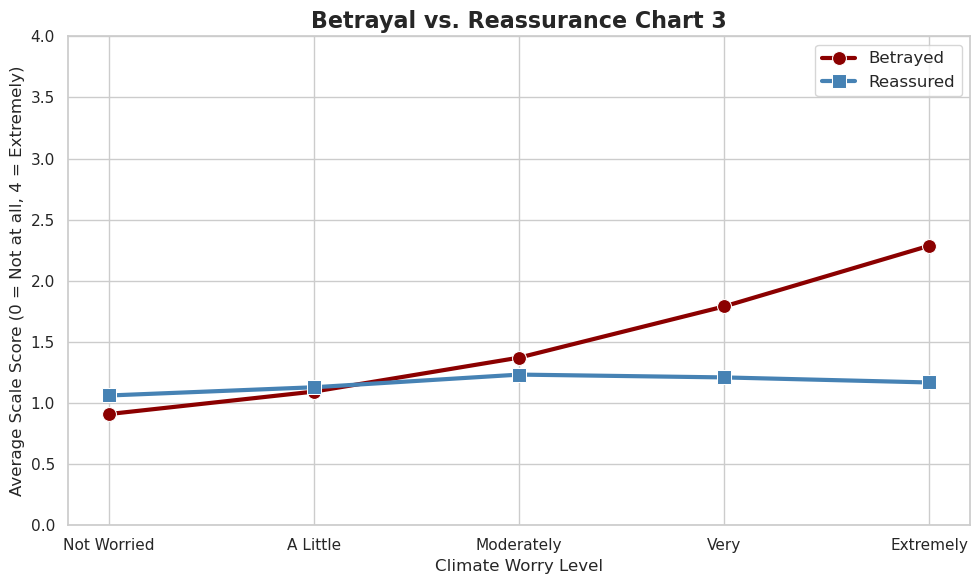

In [20]:
plt.figure(figsize=(10, 6))

# average reassurance and betrayal scores for each level of climate worry
trends = df_clean.groupby('worry_numeric')[['betrayal_scale', 'reassurance_scale']].mean().reset_index()

sns.lineplot(
    data=trends, 
    x='worry_numeric', 
    y='betrayal_scale', 
    marker='o', 
    markersize=10, 
    linewidth=3, 
    color='darkred', 
    label='Betrayed'
)

sns.lineplot(
    data=trends, 
    x='worry_numeric', 
    y='reassurance_scale', 
    marker='s', 
    markersize=10, 
    linewidth=3, 
    color='steelblue', 
    label='Reassured'
)

plt.title('Betrayal vs. Reassurance Chart 3', fontsize=16, weight='bold')
plt.xlabel('Climate Worry Level', fontsize=12)
plt.ylabel('Average Scale Score (0 = Not at all, 4 = Extremely)', fontsize=12)

plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['Not Worried', 'A Little', 'Moderately', 'Very', 'Extremely'])
plt.ylim(0, 4) 
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()